# 几种朴素贝叶斯之间的对比

## 1. 下载并引用所需要的库

In [23]:
!pip install -q nltk gensim

import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection   import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics           import accuracy_score, classification_report
from sklearn.naive_bayes      import MultinomialNB, BernoulliNB, ComplementNB

## 2. 读取数据集

读取数据集，然后简单查看数据集的情况

In [24]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
print('Shape:', df.shape)
print(df['sentiment'].value_counts())
df.head(5)

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 3. 预处理

对于标签，将 `positive` 和 `negative` 改成 `1` 和 `0`

对于已经处理完的评论，我们需要：
1. 去除无用的 html 信息（如第2条数据中的 `<br />`）
2. 把所有英文字母转成小写
3. 去除小写英文字母和空格以外的其他符号，如数字和标点
4. 分词
5. 将不同词性的单词进行词形还原
6. 去除设定好的停用词

最后可选择一行数据输出，查看预处理效果

In [36]:
def preprocess(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    STOP_WORDS  = set(stopwords.words('english'))
    lemmatizer  = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

df['clean'] = df['review'].apply(preprocess)
df['label'] = (df['sentiment'] == 'positive').astype(int)

print('Original:', df['review'].iloc[0][:3141])
print('Cleaned :', df['clean'].iloc[0][:3141])

Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

## 4. 划分测试集与训练集

测试集比例为 $20\%$

In [26]:
X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 40,000  |  Test: 10,000


## 5. 特征工程

采用 BoW 和 TF-IDF 两种方式提取特征

N-gram 设置为 1~2，设置到 3 大幅提高了本步骤时间，但对最后结果贡献微小（不足 $0.1\%$）

特别地，考虑到贝叶斯 NB 的需求，我们在 BoW 的基础上进行二值化以供其使用

In [34]:
bow = CountVectorizer(max_features=30_000, ngram_range=(1,2))
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

X_train_bern = (X_train_bow > 0).astype(int)
X_test_bern = (X_test_bow > 0).astype(int)

print(f'BoW   matrix: {X_train_bow.shape}')
print(f'TF-IDF matrix: {X_train_tfidf.shape}')
print(f'Bern matrix: {X_train_bern.shape}')

BoW   matrix: (40000, 30000)
TF-IDF matrix: (40000, 30000)
Bern matrix: (40000, 30000)


## 6. 模型训练与对比

理论上，MNB 应该使用 BoW 的数据，但是实际情况中，使用 TF-IDF 的效果会好一些。因此，我们同时在两种数据上分别训练 MNB 模型，并最后进行对比

将训练数据分为五折，通过 GridSearchCV 搜索最佳参数组合

In [35]:
search_spaces = {
    'MultinomialNB_on_BoW': {
        'model': MultinomialNB(),
        'X_train': X_train_bow,
        'X_test': X_test_bow,
        'params': {
            'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
            'fit_prior': [True, False]
        }
    },
    'MultinomialNB_on_TF-IDF': {
        'model': MultinomialNB(),
        'X_train': X_train_tfidf,
        'X_test': X_test_tfidf,
        'params': {
            'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
            'fit_prior': [True, False]
        }
    },
    'BernoulliNB': {
        'model': BernoulliNB(),
        'X_train': X_train_bern,
        'X_test': X_test_bern,
        'params': {
            'alpha': [0.01, 0.1, 1.0, 2.0],
            'binarize': [None],
            'fit_prior': [True, False]
        }
    },
    'ComplementNB': {
        'model': ComplementNB(norm=True),
        'X_train': X_train_tfidf,
        'X_test': X_test_tfidf,
        'params': {
            'alpha': [0.01, 0.05, 0.1, 0.3, 0.5, 1.0],
            'fit_prior': [True, False]
        }
    }
}

results = {}

for name, config in search_spaces.items():
    print(f"\n{'='*50}")
    print(f"\tTuning {name}...")
    
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(config['X_train'], y_train)
    
    y_pred = grid.predict(config['X_test'])
    test_acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'best_params': grid.best_params_,
        'cv_mean': grid.best_score_,
        'test_acc': test_acc,
        'cv_scores': grid.cv_results_['mean_test_score'][grid.best_index_] 
                     if False else [s for s in grid.cv_results_['split0_test_score'] ],
        'test_preds': y_pred
    }
    
    print(f"\tBest CV: {grid.best_score_:.4f} | Test: {test_acc:.4f}")
    print(f"\tParams: {grid.best_params_}")
    print(classification_report(y_test, y_pred, target_names=['Neg', 'Pos']))


	Tuning MultinomialNB_on_BoW...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
	Best CV: 0.8688 | Test: 0.8707
	Params: {'alpha': 0.1, 'fit_prior': True}
              precision    recall  f1-score   support

         Neg       0.87      0.87      0.87      5000
         Pos       0.87      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


	Tuning MultinomialNB_on_TF-IDF...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
	Best CV: 0.8758 | Test: 0.8787
	Params: {'alpha': 0.1, 'fit_prior': True}
              precision    recall  f1-score   support

         Neg       0.89      0.87      0.88      5000
         Pos       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


	Tun

下面提供了一张热力图，通过 Cohen's Kappa 对比四种模型在测试集上的分类一致性

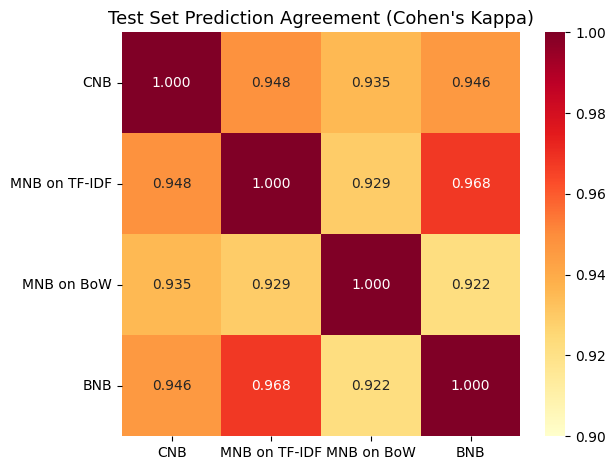

In [37]:
names = list(results.keys())
kappa_matrix = np.zeros((len(names), len(names)))

for i, n1 in enumerate(names):
    for j, n2 in enumerate(names):
        kappa_matrix[i][j] = cohen_kappa_score(
            results[n1]['test_preds'], 
            results[n2]['test_preds']
        )

names = {'MNB on BoW','MNB on TF-IDF','BNB','CNB'}
sns.heatmap(kappa_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=names, yticklabels=names, vmin=0.90, vmax=1.0)
plt.title('Test Set Prediction Agreement (Cohen\'s Kappa)', fontsize=13)
plt.tight_layout()
plt.show()

下图通过截取 y 轴更好地展示了四种模型的准确率差别，并提供了误差棒以便观察每个模型在 5 折交叉验证中准确率的波动情况

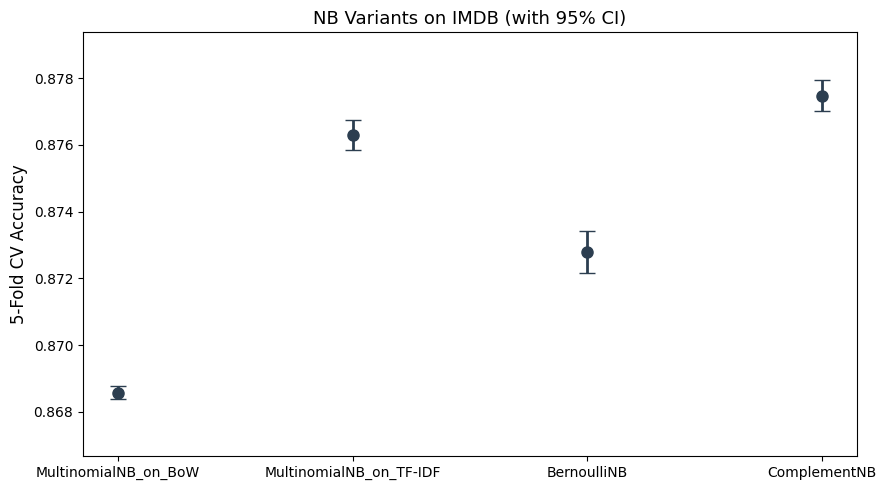

In [30]:
models = list(results.keys())
means = [results[m]['cv_mean'] for m in models]
stds = [np.std(results[m]['cv_scores']) for m in models]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(models, means, yerr=stds, fmt='o', capsize=6, markersize=8, linewidth=2, color='#2c3e50')

y_min = min(means) - 3 * max(stds)
y_max = max(means) + 3 * max(stds)
ax.set_ylim(y_min, y_max)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('NB Variants on IMDB (with 95% CI)', fontsize=13)

from statsmodels.stats.contingency_tables import mcnemar
ref_preds = results[models[0]]['test_preds']
for i, m in enumerate(models[1:], 1):
    table = [[np.sum((ref_preds==1)&(results[m]['test_preds']==1)),
              np.sum((ref_preds==1)&(results[m]['test_preds']==0))],
             [np.sum((ref_preds==0)&(results[m]['test_preds']==1)),
              np.sum((ref_preds==0)&(results[m]['test_preds']==0))]]
    p = mcnemar(table, exact=True).pvalue
    if p > 0.05:
        ax.annotate('n.s.', xy=(i, means[i]), xytext=(i, means[i]+stds[i]+0.001),
                    ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()